In [1]:
# --- 1. CORE DATA & VIZ ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
%matplotlib inline

# --- 2. STATSMODELS (Statistical Inference & Formulas) ---
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm
from statsmodels.nonparametric.smoothers_lowess import lowess

# --- 3. SKLEARN: PREPROCESSING & DATA PIPELINES ---
from sklearn.model_selection import (
    train_test_split, LeaveOneOut, KFold, 
    cross_val_score, GridSearchCV, RandomizedSearchCV
)
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, PolynomialFeatures, OneHotEncoder
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# --- 4. SKLEARN: LINEAR MODELS (Chapter 3, 4, & 6) ---
from sklearn.linear_model import (
    LinearRegression, LogisticRegression, 
    Ridge, Lasso, ElasticNet, RidgeCV, LassoCV
)

# --- 5. SKLEARN: MODEL SELECTION & DIMENSIONALITY REDUCTION (Chapter 6) ---
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression

# --- 6. SKLEARN: TREE-BASED MODELS & ENSEMBLES (Chapter 8) ---
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    RandomForestRegressor, RandomForestClassifier,
    GradientBoostingRegressor, GradientBoostingClassifier,
    BaggingRegressor, AdaBoostRegressor
)

# --- 7. SKLEARN: SUPPORT VECTOR MACHINES (Chapter 9) ---
from sklearn.svm import SVC, SVR

# --- 8. SKLEARN: NEAREST NEIGHBORS & CLUSTERING (Chapter 4 & 12) ---
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.cluster import KMeans, AgglomerativeClustering

# --- 9. SKLEARN: EVALUATION METRICS ---
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error,
    accuracy_score, confusion_matrix, classification_report, 
    roc_curve, auc, roc_auc_score, silhouette_score
)

# --- 10. UTILS & RESAMPLING ---
from sklearn.utils import resample
import warnings
warnings.filterwarnings('ignore')
from patsy import (
    dmatrix, bs
)

## Tree-Based Models (TBM)

In [2]:
df = pd.read_csv("Hitters.csv")
df.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


Text(0.5, 1.0, 'Salary Distribution')

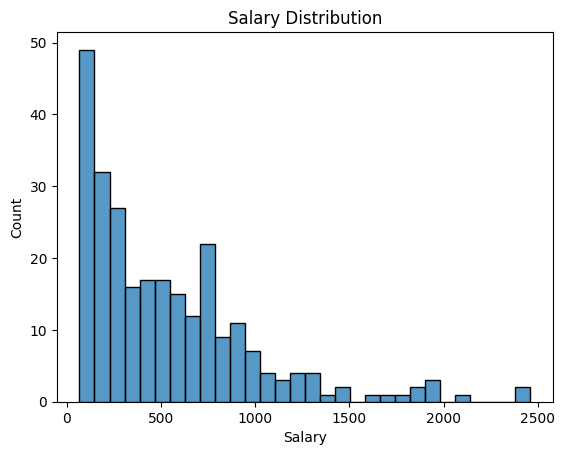

In [27]:
sns.histplot(df["Salary"], bins=30)
plt.title("Salary Distribution")

Professional sports salaries are usually strongly right-skewed:

- many players earn moderate salaries
- a small number earn extremely large salaries

This creates:

- skewness
- heteroskedasticity
- long-tailed distributions

Understanding the response distribution is important before modelling.

## Regression Trees
Using the Hitters Dataset

Goals:
- Understand regression trees conceptually
- Learn recursive binary splitting
- Understand RSS minimisation
- Visualise partitioning
- Learn overfitting and pruning
- Understand bagging and random forests

A regression tree recursively partitions the predictor space into regions.

Instead of fitting a single global equation, the model creates a sequence of binary splits.

The predictor space is divided into regions:

$$
X→ R_1, R_2, \dots, R_J
$$

For each region, the prediction is simply the average response value inside that region:

$$
\hat{y}_{R_j} = \frac{1}{N_j}\sum_{i \in R_j} y_i $$ or
$$
\hat{y}_{R_j} = mean ({y}_{i} \in {R})
$$

This produces a **piecewise constant model**.

---

### Objective Function

> Regression trees attempt to create regions where observations have similar response values. they minimise RSS:

$$
RSS = \sum_{j=1}^{J}\sum_{i \in R_j}(y_i - \hat{y}_{R_j})^2
$$

where:

- $R_j$ = region $j$
- $\hat{y}_{R_j}$ = mean response within region $R_j$

A "good" split creates regions where:

- observations are similar
- salaries within the node are close together
- variance inside each node is small

The tree searches for splits that reduce prediction error as much as possible.

In [6]:
df["Salary"].isna().sum()

np.int64(59)

In [7]:
df = df.dropna()

X = df.drop(columns=["Salary"])
y = df["Salary"]

X = pd.get_dummies(X, drop_first=True)

X.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,League_N,Division_W,NewLeague_N
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,632,43,10,True,True,True
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,880,82,14,False,True,False
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,200,11,3,True,False,True
4,321,87,10,39,42,30,2,396,101,12,48,46,33,805,40,4,True,False,True
5,594,169,4,74,51,35,11,4408,1133,19,501,336,194,282,421,25,False,True,False


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [33]:
tree = DecisionTreeRegressor(criterion='squared_error',
    max_depth=2,
    random_state=1)

tree.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=2, random_state=1)

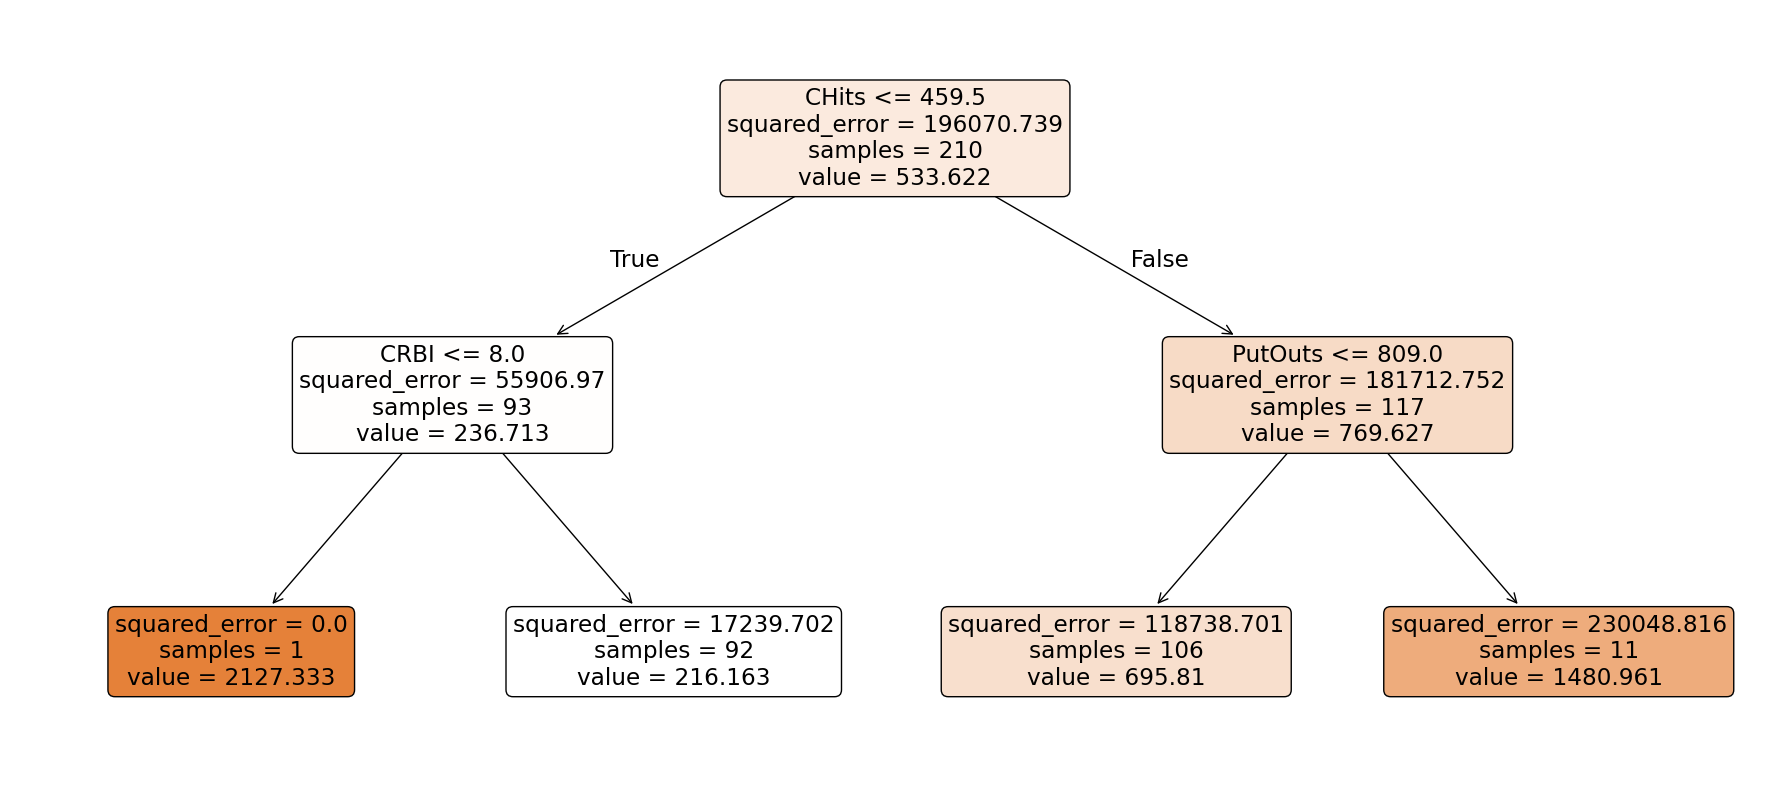

In [34]:
plt.figure(figsize=(18,8))

plot_tree(tree, feature_names=X.columns, filled=True, rounded=True)

plt.tight_layout()
plt.show()

### Recursive Binary Splitting

The tree searches over:

- predictor $j$
- split point $s$

to minimise:

$$
\sum_{i:x_i \in R_1(j,s)}(y_i - \hat{y}_{R_1})^2
+
\sum_{i:x_i \in R_2(j,s)}(y_i - \hat{y}_{R_2})^2
$$

where:

- $R_1(j,s)$ = observations satisfying $x_j < s$
- $R_2(j,s)$ = observations satisfying $x_j \ge s$

---

The algorithm is **greedy**.

At each step:

- it chooses the best immediate split
- it does NOT guarantee the globally optimal tree

This is computationally necessary because the number of possible trees grows exponentially.

In [17]:
depths = range(1, 15)

train_mse = []
test_mse = []

for depth in depths:

    model = DecisionTreeRegressor(
        max_depth=depth,
        random_state=1
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_mse.append(
        mean_squared_error(y_train, train_pred)
    )

    test_mse.append(
        mean_squared_error(y_test, test_pred)
    )

results = pd.DataFrame({
    "Depth": depths,
    "Train_MSE": train_mse,
    "Test_MSE": test_mse
})
results["Gap"] = (
    results["Test_MSE"] - results["Train_MSE"]
)

results


,Depth,Train_MSE,Test_MSE,Gap
0,1,125998.762947,131689.704019,5690.941072
1,2,79537.580411,177403.675142,97866.094731
2,3,55303.871636,174263.015054,118959.143418
3,4,33645.071603,142223.432512,108578.360909
4,5,22306.808399,169624.183660,147317.375260
5,6,15329.680087,142176.382325,126846.702238
6,7,11725.549138,164367.560175,152642.011036
7,8,7007.891569,190220.260787,183212.369218
8,9,3386.087333,169875.318323,166489.230991
9,10,1132.423085,196478.878886,195346.455801


The generalisation gap measures:

$$
\text{Test Error} - \text{Train Error}
$$

As tree depth increases:

- training error decreases
- the gap widens
- variance increases

A large gap is often evidence of overfitting.

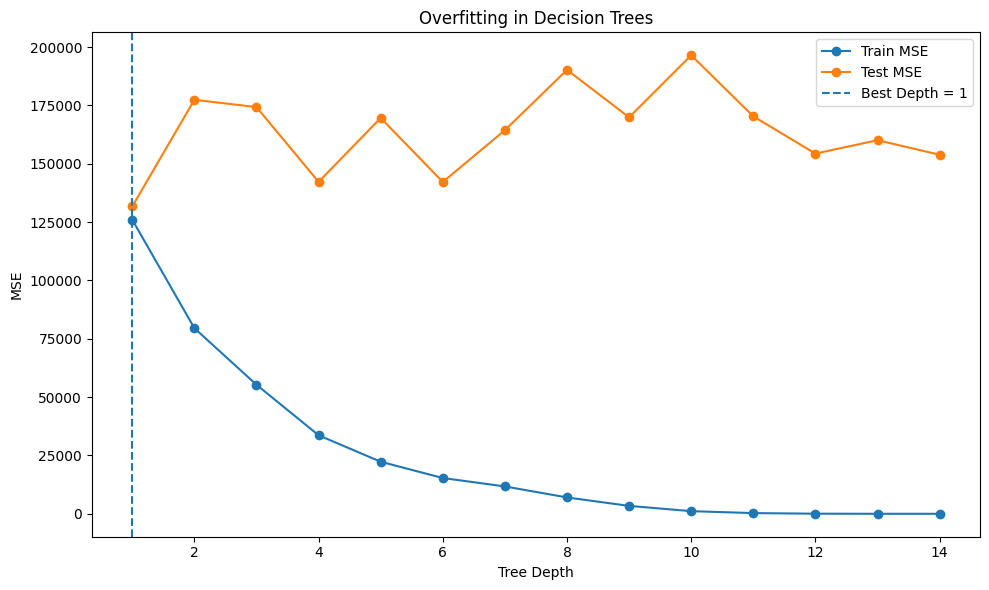

In [20]:
best_depth = results.loc[
    results["Test_MSE"].idxmin(),
    "Depth"
]
best_depth

plt.figure(figsize=(10,6))
plt.plot(depths, train_mse, marker="o", label="Train MSE")
plt.plot(depths, test_mse, marker="o", label="Test MSE")
plt.axvline(best_depth, linestyle="--", label=f"Best Depth = {best_depth}")
plt.xlabel("Tree Depth")
plt.ylabel("MSE")
plt.title("Overfitting in Decision Trees")

plt.legend()
plt.tight_layout()
plt.show()

### Interpretation of the Overfitting Curve


#### 1. Training Error Always Decreases

As tree depth increases:

- the model becomes more flexible
- additional splits reduce RSS
- the tree can fit increasingly complex patterns

In the limit, a sufficiently deep tree can nearly memorise the training data.

---

#### 2. Test Error Eventually Increases

Initially:

- increasing flexibility improves generalisation

However, after some point:

- the tree begins fitting noise
- variance increases
- out-of-sample performance deteriorates

This is the classical overfitting phenomenon.

---

#### 3. Trees Have High Variance

Small perturbations in the data can produce:

- different splits
- different structures
- different predictions

This instability motivates ensemble methods such as:

- bagging
- random forests
- boosting

### Testing Different Depths

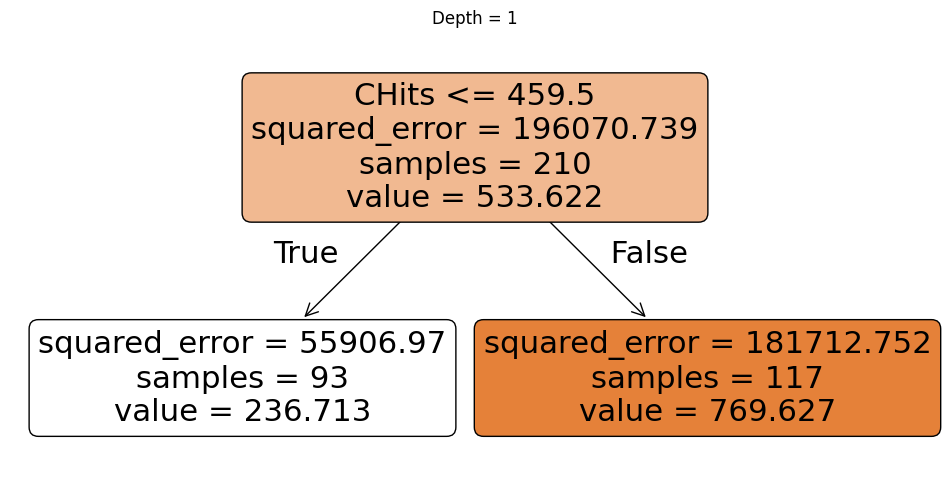

In [25]:
small_tree = DecisionTreeRegressor(
    max_depth=1,
    random_state=1
)

small_tree.fit(X_train, y_train)

plt.figure(figsize=(12,6))

plot_tree(
    small_tree,
    feature_names=X.columns,
    filled=True,
    rounded=True
)

plt.title("Depth = 1")

plt.show()

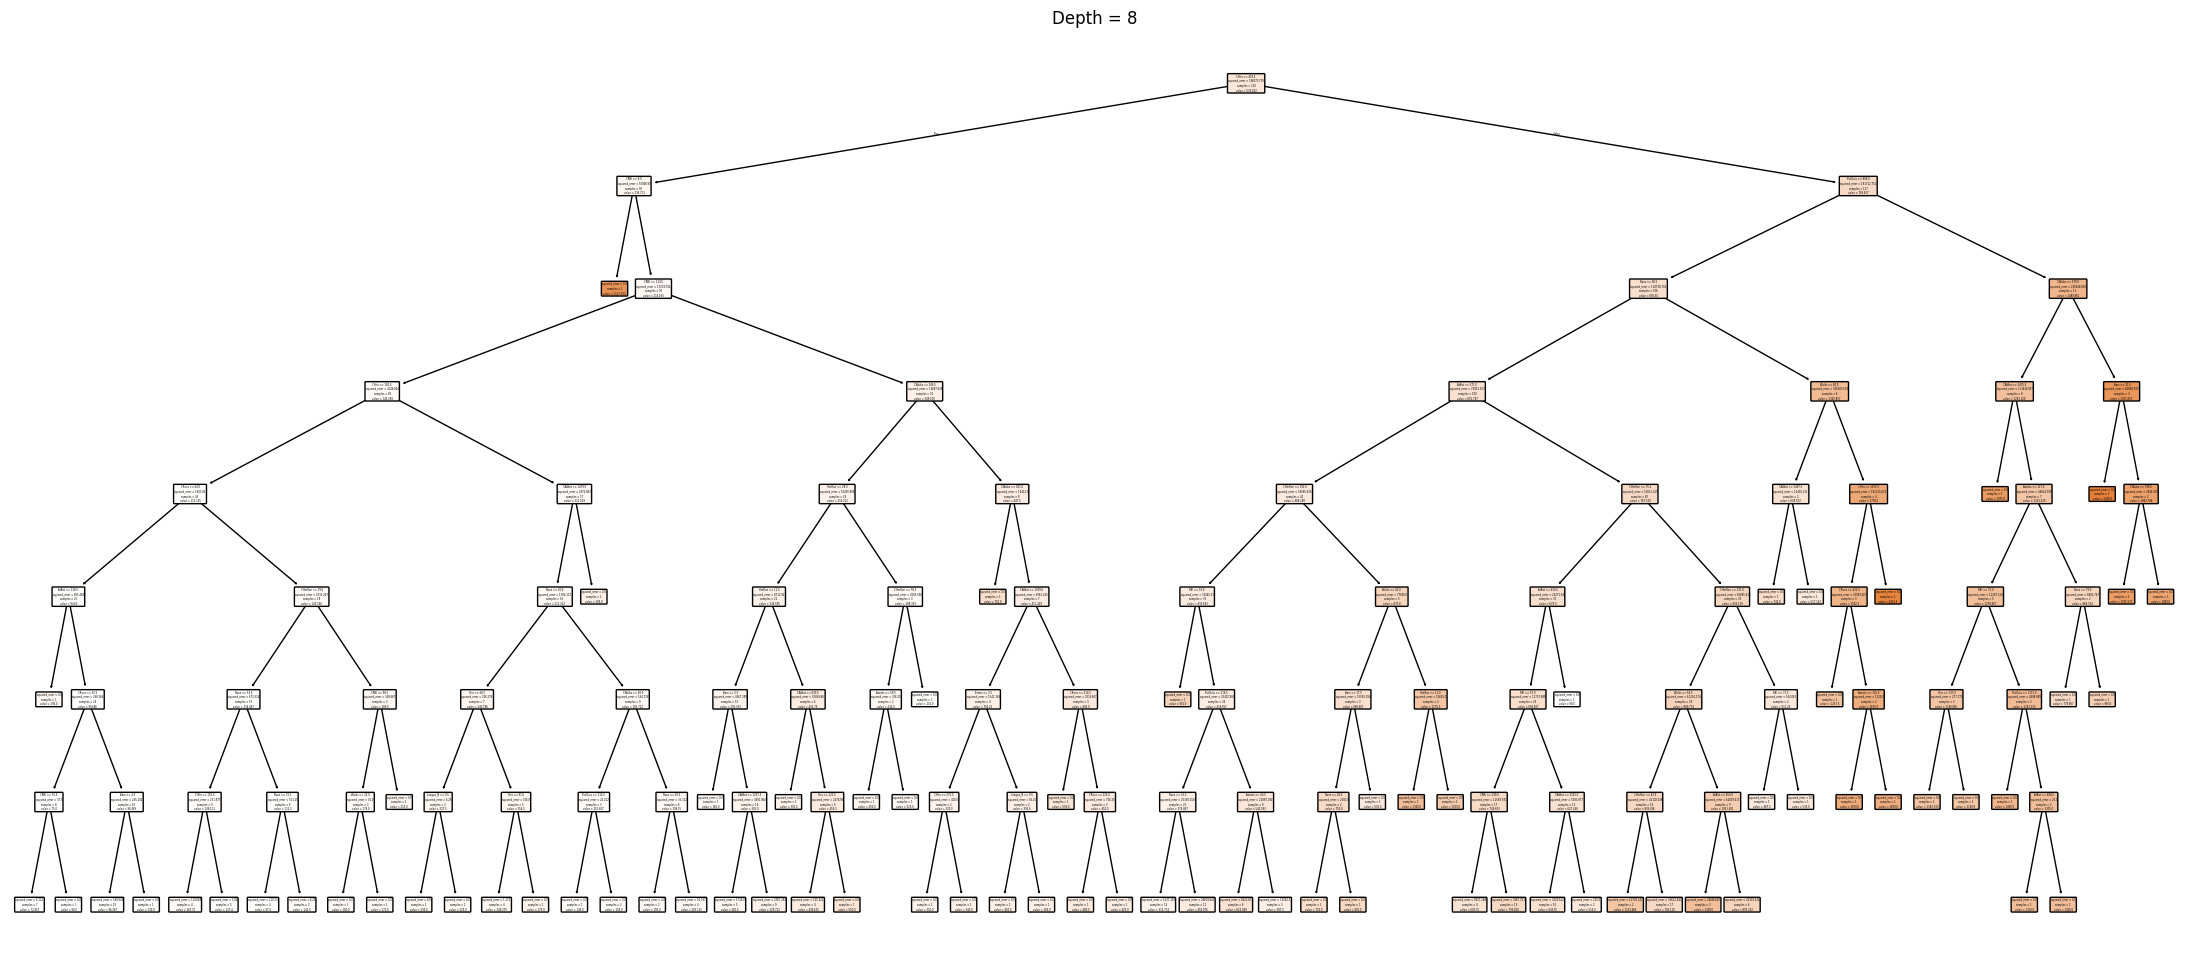

In [26]:
large_tree = DecisionTreeRegressor(
    max_depth=8,
    random_state=1
)

large_tree.fit(X_train, y_train)

plt.figure(figsize=(28,12))

plot_tree(
    large_tree,
    feature_names=X.columns,
    filled=True,
    rounded=True
)

plt.title("Depth = 8")

plt.show()